In [1]:
import pandas as pd
import numpy as np

In [7]:
import pickle
import pandas as pd

# 선택한 피처 목록 불러오기
with open('selected_features.pkl', 'rb') as f:
    selected_features = pickle.load(f)

# 데이터프레임 불러오기
df_selected = pd.read_pickle('selected_data.pkl')

#타겟변수를 불러오기 위해 원본데이터 로드
df=pd.read_csv('./xAPI-Edu-Data.csv')

In [3]:
selected_features

['raisedhands',
 'StudentAbsenceDays_Under-7',
 'VisITedResources',
 'Relation_Mum',
 'AnnouncementsView',
 'ParentAnsweringSurvey_Yes',
 'Discussion',
 'gender_M']

In [ ]:
# 피처 X, 타겟 y 설정
X = df_selected 
y = df['Class']

In [ ]:
from sklearn.model_selection import train_test_split

# 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [25]:
#수치형 변수 선택
numeric_cols = df_selected.select_dtypes(include='int64').columns.tolist()
print(numeric_cols)

['raisedhands', 'VisITedResources', 'AnnouncementsView', 'Discussion']


In [26]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score, GridSearchCV

#모델 정의

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, multi_class='multinomial', solver='lbfgs', random_state=42),
    'Random Forest_lg': RandomForestClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42, objective='multi:softprob',eval_metric='mlogloss'),
    'SVM': SVC(probability=True, random_state=42)
}

#### Random Forest 회귀모델, XGBoost 모델은 문자열 형태의 레이블 처리 불가
#### => labelEncoder사용

In [41]:
from sklearn.preprocessing import LabelEncoder
# 레이블 인코딩
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

# 모델 학습 및 평가
results = {}
for name, model in models.items():
    # 교차 검증
    cv_scores = cross_val_score(model, X_train_scaled, y_train_encoded, cv=5, scoring='accuracy')
    
    # 모델 학습
    model.fit(X_train_scaled, y_train_encoded)
    
    # 예측
    y_pred = model.predict(X_test_scaled)
    
    # 성능 평가
    accuracy = accuracy_score(y_test_encoded, y_pred)
    report = classification_report(y_test_encoded, y_pred)
    
    # 결과 저장
    results[name] = {
        'model': model,
        'cv_scores': cv_scores,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'test_accuracy': accuracy,
        'classification_report': report
    }
    
    print(f"\n{name} 결과:")
    print(f"교차 검증 정확도: {cv_scores.mean():.4f} (±{cv_scores.std():.4f})")
    print(f"테스트 정확도: {accuracy:.4f}")
    print("분류 보고서:")
    print(report)


Logistic Regression 결과:
교차 검증 정확도: 0.7786 (±0.0250)
테스트 정확도: 0.7188
분류 보고서:
              precision    recall  f1-score   support

           0       0.65      0.59      0.62        29
           1       0.85      0.92      0.88        25
           2       0.67      0.69      0.68        42

    accuracy                           0.72        96
   macro avg       0.73      0.73      0.73        96
weighted avg       0.71      0.72      0.72        96


Random Forest_lg 결과:
교차 검증 정확도: 0.7812 (±0.0228)
테스트 정확도: 0.7708
분류 보고서:
              precision    recall  f1-score   support

           0       0.80      0.69      0.74        29
           1       0.79      0.92      0.85        25
           2       0.74      0.74      0.74        42

    accuracy                           0.77        96
   macro avg       0.78      0.78      0.78        96
weighted avg       0.77      0.77      0.77        96


XGBoost 결과:
교차 검증 정확도: 0.7630 (±0.0156)
테스트 정확도: 0.7917
분류 보고서:
              precisio

### Random Search를 통한 탐색
#### n_iter= 인자를 통해서 가능한 조합 탐색

In [ ]:
from scipy.stats import uniform, randint
from sklearn.model_selection import RandomizedSearchCV

#1. 로지스틱 회귀 랜덤 서치

log_reg_params = {
    'C': uniform(0.01, 100),  # 0.01에서 100 사이의 균일 분포
    'solver': ['saga', 'lbfgs'],
    'max_iter': randint(100, 1000),
    'penalty': ['l1', 'l2', 'elasticnet', 'none']
}

log_reg = LogisticRegression(multi_class='multinomial', random_state=42)
log_reg_random = RandomizedSearchCV(
    estimator=log_reg,
    param_distributions=log_reg_params,
    n_iter=250,  # n_iter번의 랜덤 조합 시도
    cv=5,
    verbose=1,
    random_state=44,
    n_jobs=-1
)

# 랜덤 서치 실행
log_reg_random.fit(X_train_scaled, y_train_encoded)
print("로지스틱 회귀 최적 파라미터:", log_reg_random.best_params_)
print("로지스틱 회귀 최고 정확도:", log_reg_random.best_score_)

Fitting 5 folds for each of 250 candidates, totalling 1250 fits
로지스틱 회귀 최적 파라미터: {'C': 83.49421486656495, 'max_iter': 853, 'penalty': 'l2', 'solver': 'lbfgs'}
로지스틱 회귀 최고 정확도: 0.7812371838687628


c:\ProgramData\anaconda3\envs\conda_env\lib\site-packages\sklearn\model_selection\_validation.py:378: FitFailedWarning: 
515 fits failed out of a total of 1250.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
185 fits failed with the following error:
Traceback (most recent call last):
  File "c:\ProgramData\anaconda3\envs\conda_env\lib\site-packages\sklearn\model_selection\_validation.py", line 686, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\ProgramData\anaconda3\envs\conda_env\lib\site-packages\sklearn\linear_model\_logistic.py", line 1162, in fit
    solver = _check_solver(self.solver, self.penalty, self.dual)
  File "c:\ProgramData\anaconda3\envs\conda_env\lib\site-packages\sklearn\linear_model\_log

In [50]:
# 2.랜덤 포레스트 랜덤 서치
from scipy.stats import randint
from sklearn.model_selection import RandomizedSearchCV

rf_params = {
    'n_estimators': randint(100, 500),
    'max_depth': randint(5, 30),
    'min_samples_split': randint(2, 20),
    'min_samples_leaf': randint(1, 10),
    'max_features': ['sqrt', 'log2', None],
    'bootstrap': [True, False]
}

rf = RandomForestClassifier(random_state=42)
rf_random = RandomizedSearchCV(
    estimator=rf,
    param_distributions=rf_params,
    n_iter=150,
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

# 랜덤 서치 실행
rf_random.fit(X_train_scaled, y_train_encoded)
print("랜덤 포레스트 최적 파라미터:", rf_random.best_params_)
print("랜덤 포레스트 최고 정확도:", rf_random.best_score_)

Fitting 5 folds for each of 150 candidates, totalling 750 fits
랜덤 포레스트 최적 파라미터: {'bootstrap': False, 'max_depth': 21, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 17, 'n_estimators': 316}
랜덤 포레스트 최고 정확도: 0.786431989063568


In [51]:
from scipy.stats import randint,uniform
from sklearn.model_selection import RandomizedSearchCV

# 3. XGBoost 랜덤 서치
xgb_params = {
    'max_depth': randint(1, 10),
    'learning_rate': uniform(0.01, 0.3),
    'n_estimators': randint(50, 500),
    'subsample': uniform(0.5, 0.5),  # 0.5에서 1.0 사이
    'colsample_bytree': uniform(0.5, 0.5),  # 0.5에서 1.0 사이
    'gamma': uniform(0, 1),
    'min_child_weight': randint(1, 10)
}

xgb = XGBClassifier(objective='multi:softprob', eval_metric='mlogloss', random_state=42)
xgb_random = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=xgb_params,
    n_iter=150,
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

# 랜덤 서치 실행
xgb_random.fit(X_train_scaled, y_train_encoded)
print("XGBoost 최적 파라미터:", xgb_random.best_params_)
print("XGBoost 최고 정확도:", xgb_random.best_score_)

Fitting 5 folds for each of 150 candidates, totalling 750 fits
XGBoost 최적 파라미터: {'colsample_bytree': 0.8216441092211766, 'gamma': 0.45825289049151663, 'learning_rate': 0.17368503679478048, 'max_depth': 5, 'min_child_weight': 3, 'n_estimators': 114, 'subsample': 0.9805952819119571}
XGBoost 최고 정확도: 0.7889952153110048


In [52]:
from scipy.stats import randint,uniform
from sklearn.model_selection import RandomizedSearchCV

# 4. SVM 랜덤 서치
svm_params = {
    'C': uniform(0.1, 100),
    'kernel': ['linear', 'poly', 'rbf', 'sigmoid'],
    'gamma': ['scale', 'auto'] + list(uniform(0.0001, 10).rvs(10)),
    'degree': randint(2, 5)  # poly 커널에만 적용
}

svm = SVC(probability=True, random_state=42)
svm_random = RandomizedSearchCV(
    estimator=svm,
    param_distributions=svm_params,
    n_iter=150,
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

# 랜덤 서치 실행
svm_random.fit(X_train_scaled, y_train_encoded)
print("SVM 최적 파라미터:", svm_random.best_params_)
print("SVM 최고 정확도:", svm_random.best_score_)

# 최적 모델 비교
best_models = {
    'Logistic Regression': log_reg_random.best_estimator_,
    'Random Forest': rf_random.best_estimator_,
    'XGBoost': xgb_random.best_estimator_,
    'SVM': svm_random.best_estimator_
}

Fitting 5 folds for each of 150 candidates, totalling 750 fits
SVM 최적 파라미터: {'C': 4.018632667564625, 'degree': 2, 'gamma': 8.754068994483161, 'kernel': 'linear'}
SVM 최고 정확도: 0.7812713602187287


### 정확도 말고 F1스코어와 auc-roc로 확인

In [55]:
# 로지스틱 회귀
scoring = {
    'accuracy': 'accuracy',
    'f1': 'f1_weighted',
    'recall': 'recall_weighted',
    'roc_auc': 'roc_auc_ovr'
}

# 1. 로지스틱 회귀 랜덤 서치 (수정된 파라미터)
log_reg_params = [
    {'solver': ['saga'], 'penalty': ['l1', 'l2', 'elasticnet', None], 'C': uniform(0.01, 100)},
    {'solver': ['lbfgs'], 'penalty': ['l2', None], 'C': uniform(0.01, 100)}
]

log_reg = LogisticRegression(multi_class='multinomial', random_state=42, max_iter=1000)
log_reg_random = RandomizedSearchCV(
    estimator=log_reg,
    param_distributions=log_reg_params,
    n_iter=150,
    cv=5,
    scoring=scoring,
    refit='f1',  # F1 점수 기준으로 최적화
    verbose=1,
    random_state=42,
    n_jobs=-1
)

log_reg_random.fit(X_train_scaled, y_train_encoded)

# 모든 지표의 결과 확인
results_df = pd.DataFrame(log_reg_random.cv_results_)
best_index = log_reg_random.best_index_

print("최적 모델의 다양한 평가 지표:")
print(f"Accuracy: {results_df.loc[best_index, 'mean_test_accuracy']:.4f}")
print(f"F1 Score: {results_df.loc[best_index, 'mean_test_f1']:.4f}")
print(f"Recall: {results_df.loc[best_index, 'mean_test_recall']:.4f}")
print(f"ROC-AUC: {results_df.loc[best_index, 'mean_test_roc_auc']:.4f}")

Fitting 5 folds for each of 150 candidates, totalling 750 fits
최적 모델의 다양한 평가 지표:
Accuracy: 0.7812
F1 Score: 0.7794
Recall: 0.7812
ROC-AUC: 0.9136


c:\ProgramData\anaconda3\envs\conda_env\lib\site-packages\sklearn\model_selection\_validation.py:378: FitFailedWarning: 
80 fits failed out of a total of 750.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
80 fits failed with the following error:
Traceback (most recent call last):
  File "c:\ProgramData\anaconda3\envs\conda_env\lib\site-packages\sklearn\model_selection\_validation.py", line 686, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\ProgramData\anaconda3\envs\conda_env\lib\site-packages\sklearn\linear_model\_logistic.py", line 1291, in fit
    fold_coefs_ = Parallel(n_jobs=self.n_jobs, verbose=self.verbose, prefer=prefer)(
  File "c:\ProgramData\anaconda3\envs\conda_env\lib\site-packages\joblib\p

In [ ]:
# 랜덤포레스트 여러 평가 지표 정의
scoring = {
    'accuracy': 'accuracy',
    'f1': 'f1_weighted',
    'recall': 'recall_weighted',
    'roc_auc': 'roc_auc_ovr'
}

# 여러 지표를 계산하고 F1 점수로 최적화
rf_random_multi = RandomizedSearchCV(
    estimator=rf,
    param_distributions=rf_params,
    n_iter=150,
    cv=5,
    scoring=scoring,
    refit='f1',  # F1 점수를 기준으로 최적 모델 선택
    verbose=1,
    random_state=42,
    n_jobs=-1
)

rf_random_multi.fit(X_train_scaled, y_train_encoded)

# 모든 지표의 결과 확인
results_df = pd.DataFrame(rf_random_multi.cv_results_)
best_index = rf_random_multi.best_index_

print("최적 모델의 다양한 평가 지표:")
print(f"Accuracy: {results_df.loc[best_index, 'mean_test_accuracy']:.4f}")
print(f"F1 Score: {results_df.loc[best_index, 'mean_test_f1']:.4f}")
print(f"Recall: {results_df.loc[best_index, 'mean_test_recall']:.4f}")
print(f"ROC-AUC: {results_df.loc[best_index, 'mean_test_roc_auc']:.4f}")


Fitting 5 folds for each of 150 candidates, totalling 750 fits
최적 모델의 다양한 평가 지표:
Accuracy: 0.7864
F1 Score: 0.7848
Recall: 0.7864
ROC-AUC: 0.9184


In [ ]:
# 3. XGBoost 랜덤 서치
scoring = {
    'accuracy': 'accuracy',
    'f1': 'f1_weighted',
    'recall': 'recall_weighted',
    'roc_auc': 'roc_auc_ovr'
}

xgb_params = {
    'max_depth': randint(1, 10),
    'learning_rate': uniform(0.01, 0.3),
    'n_estimators': randint(50, 500),
    'subsample': uniform(0.5, 0.5),  # 0.5에서 1.0 사이
    'colsample_bytree': uniform(0.5, 0.5),  # 0.5에서 1.0 사이
    'gamma': uniform(0, 1),
    'min_child_weight': randint(1, 10)
}

xgb = XGBClassifier(objective='multi:softprob', eval_metric='mlogloss', random_state=42)
xgb_random = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=xgb_params,
    n_iter=150,
    cv=5,
    scoring=scoring,
    refit='f1',  # F1 점수 기준으로 최적화
    verbose=1,
    random_state=42,
    n_jobs=-1
)

xgb_random.fit(X_train_scaled, y_train_encoded)

# 모든 지표의 결과 확인
results_df = pd.DataFrame(xgb_random.cv_results_)
best_index = xgb_random.best_index_

print("최적 모델의 다양한 평가 지표:")
print(f"Accuracy: {results_df.loc[best_index, 'mean_test_accuracy']:.4f}")
print(f"F1 Score: {results_df.loc[best_index, 'mean_test_f1']:.4f}")
print(f"Recall: {results_df.loc[best_index, 'mean_test_recall']:.4f}")
print(f"ROC-AUC: {results_df.loc[best_index, 'mean_test_roc_auc']:.4f}")

Fitting 5 folds for each of 150 candidates, totalling 750 fits
최적 모델의 다양한 평가 지표:
Accuracy: 0.7890
F1 Score: 0.7884
Recall: 0.7890
ROC-AUC: 0.9091


In [77]:
# 4. svm

scoring = {
    'accuracy': 'accuracy',
    'f1': 'f1_weighted',
    'recall': 'recall_weighted',
    'roc_auc': 'roc_auc_ovr'
}

svm_params = {
    'C': uniform(0.1, 100),
    'kernel': ['linear', 'poly', 'rbf', 'sigmoid'],
    'gamma': ['scale', 'auto'] + list(uniform(0.0001, 10).rvs(10)),
    'degree': randint(2, 5)  # poly 커널에만 적용
}

svm = SVC(probability=True, random_state=42)
svm_random = RandomizedSearchCV(
    estimator=svm,
    param_distributions=svm_params,
    n_iter=100,
    cv=5,
    scoring=scoring,
    refit='f1',  # F1 점수 기준으로 최적화
    verbose=1,
    random_state=42,
    n_jobs=-1
)

svm_random.fit(X_train_scaled, y_train_encoded)

# 모든 지표의 결과 확인
results_df = pd.DataFrame(svm_random.cv_results_)
best_index = svm_random.best_index_

print("최적 모델의 다양한 평가 지표:")
print(f"Accuracy: {results_df.loc[best_index, 'mean_test_accuracy']:.4f}")
print(f"F1 Score: {results_df.loc[best_index, 'mean_test_f1']:.4f}")
print(f"Recall: {results_df.loc[best_index, 'mean_test_recall']:.4f}")
print(f"ROC-AUC: {results_df.loc[best_index, 'mean_test_roc_auc']:.4f}")

Fitting 5 folds for each of 100 candidates, totalling 500 fits
최적 모델의 다양한 평가 지표:
Accuracy: 0.7787
F1 Score: 0.7767
Recall: 0.7787
ROC-AUC: 0.9101


In [ ]:
#모델들 종합 평가

models_ = {'log_reg': log_reg_random, 
          'rf': rf_random, 
          'xgb': xgb_random, 
          'svm': svm_random}

for model_name, model in models_.items():
    # 최적 모델 가져오기
    best_model = model.best_estimator_
    
    # 결과 확인
    results_df = pd.DataFrame(model.cv_results_)
    best_index = model.best_index_
    
    print(f"\n{model_name} 최적 파라미터:", model.best_params_)
    print(f"{model_name} 교차 검증 결과:")
    
    # 랜덤 포레스트는 다른 형식의 결과를 가짐
    if model_name == 'rf':
        print(f"Score: {results_df.loc[best_index, 'mean_test_score']:.4f}")
    else:
        # 다른 모델들은 각 지표별 결과를 출력
        print(f"Accuracy: {results_df.loc[best_index, 'mean_test_accuracy']:.4f}")
        print(f"F1 Score: {results_df.loc[best_index, 'mean_test_f1']:.4f}")
        print(f"Recall: {results_df.loc[best_index, 'mean_test_recall']:.4f}")
        print(f"ROC-AUC: {results_df.loc[best_index, 'mean_test_roc_auc']:.4f}")
    
    # 테스트 세트에서 성능 평가
    y_pred = best_model.predict(X_test_scaled)
    
    from sklearn.metrics import accuracy_score, f1_score, recall_score, roc_auc_score
    
    test_accuracy = accuracy_score(y_test_encoded, y_pred)
    test_f1 = f1_score(y_test_encoded, y_pred, average='weighted')
    test_recall = recall_score(y_test_encoded, y_pred, average='weighted')
    
    print(f"\n{model_name} 테스트 세트 성능:")
    print(f"Accuracy: {test_accuracy:.4f}")
    print(f"F1 Score: {test_f1:.4f}")
    print(f"Recall: {test_recall:.4f}")
    
    # ROC-AUC 계산 (predict_proba 메서드가 있는 경우)
    if hasattr(best_model, "predict_proba"):
        y_proba = best_model.predict_proba(X_test_scaled)
        test_roc_auc = roc_auc_score(y_test_encoded, y_proba, multi_class='ovr')
        print(f"ROC-AUC: {test_roc_auc:.4f}")
    else:
        print("ROC-AUC: Not available")



log_reg 최적 파라미터: {'C': 77.97910002727693, 'penalty': 'l1', 'solver': 'saga'}
log_reg 교차 검증 결과:
Accuracy: 0.7812
F1 Score: 0.7794
Recall: 0.7812
ROC-AUC: 0.9136

log_reg 테스트 세트 성능:
Accuracy: 0.6875
F1 Score: 0.6865
Recall: 0.6875
ROC-AUC: 0.8633

rf 최적 파라미터: {'bootstrap': False, 'max_depth': 21, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 17, 'n_estimators': 316}
rf 교차 검증 결과:
Score: 0.7864

rf 테스트 세트 성능:
Accuracy: 0.7083
F1 Score: 0.7072
Recall: 0.7083
ROC-AUC: 0.8672

xgb 최적 파라미터: {'colsample_bytree': 0.8216441092211766, 'gamma': 0.45825289049151663, 'learning_rate': 0.17368503679478048, 'max_depth': 5, 'min_child_weight': 3, 'n_estimators': 114, 'subsample': 0.9805952819119571}
xgb 교차 검증 결과:
Accuracy: 0.7890
F1 Score: 0.7884
Recall: 0.7890
ROC-AUC: 0.9091

xgb 테스트 세트 성능:
Accuracy: 0.7500
F1 Score: 0.7472
Recall: 0.7500
ROC-AUC: 0.8815

svm 최적 파라미터: {'C': 60.21150117432088, 'degree': 4, 'gamma': 9.518787836988075, 'kernel': 'linear'}
svm 교차 검증 결과:
Accuracy: 0.7

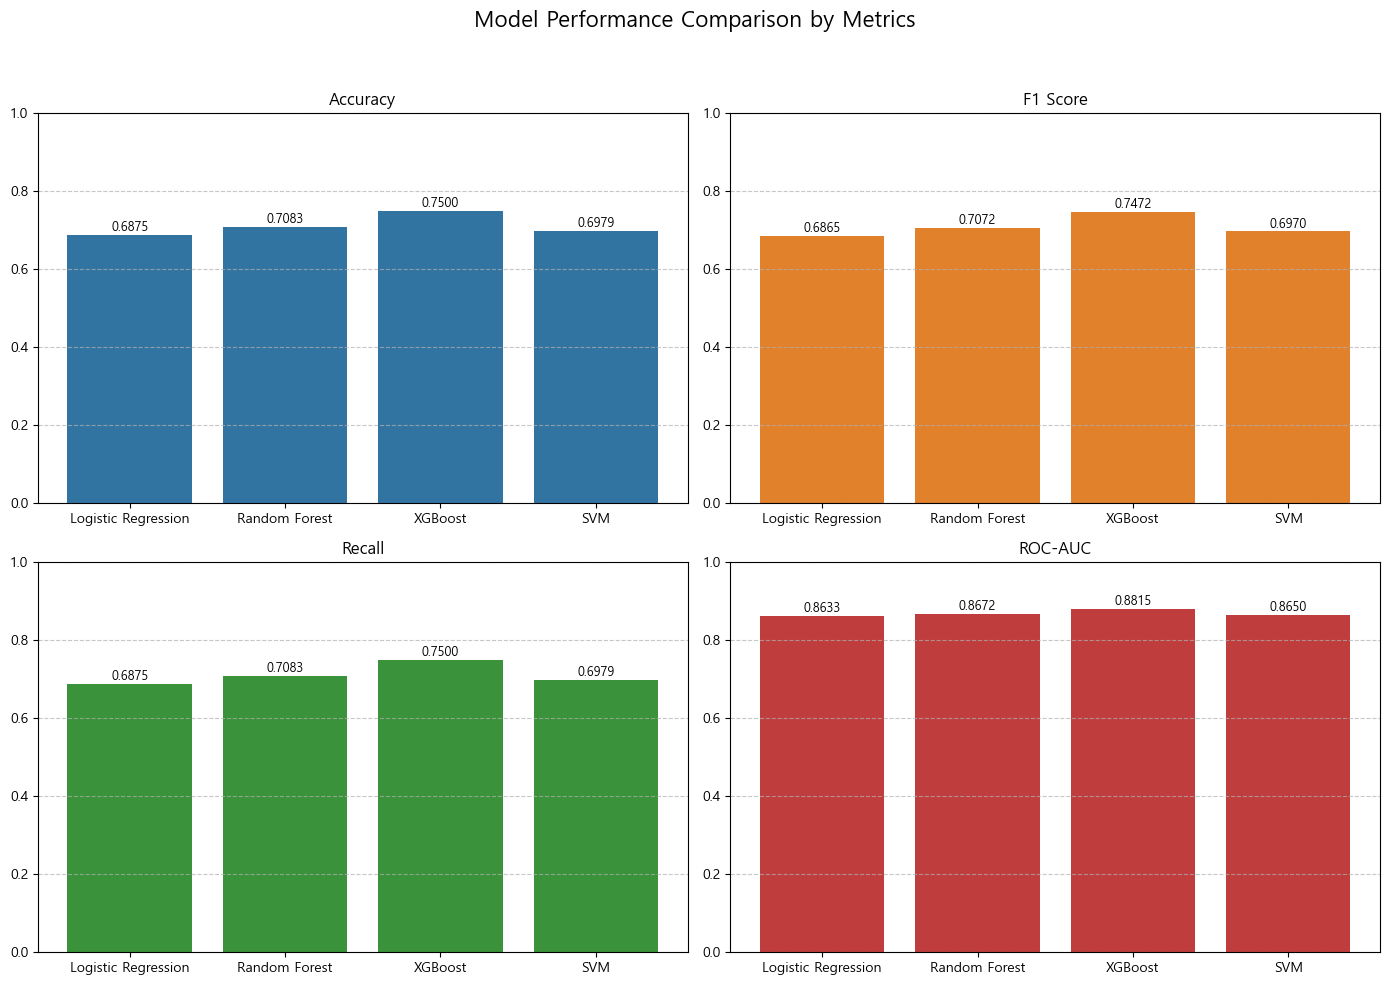

In [83]:
import matplotlib.pyplot as plt
import numpy as np

# 모델 이름
models = ['Logistic Regression', 'Random Forest', 'XGBoost', 'SVM']

# 테스트 세트 성능
accuracy = [0.6875, 0.7083, 0.7500, 0.6979]
F1_score = [0.6865, 0.7072, 0.7472, 0.6970]
recall = [0.6875, 0.7083, 0.7500, 0.6979]
roc_auc = [0.8633, 0.8672, 0.8815, 0.8650]

# 2x2 서브플롯 생성
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Model Performance Comparison by Metrics', fontsize=16)

# 각 지표별 서브플롯
metrics = [accuracy, F1_score, recall, roc_auc]
titles = ['Accuracy', 'F1 Score', 'Recall', 'ROC-AUC']
colors = ['#3274A1', '#E1812C', '#3A923A', '#C03D3E']

for i, (ax, metric, title, color) in enumerate(zip(axes.flatten(), metrics, titles, colors)):
    bars = ax.bar(models, metric, color=color)
    ax.set_title(title, fontsize=12)
    ax.set_ylim(0, 1.0)
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    
    # 값 표시
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.4f}', ha='center', fontsize=9)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


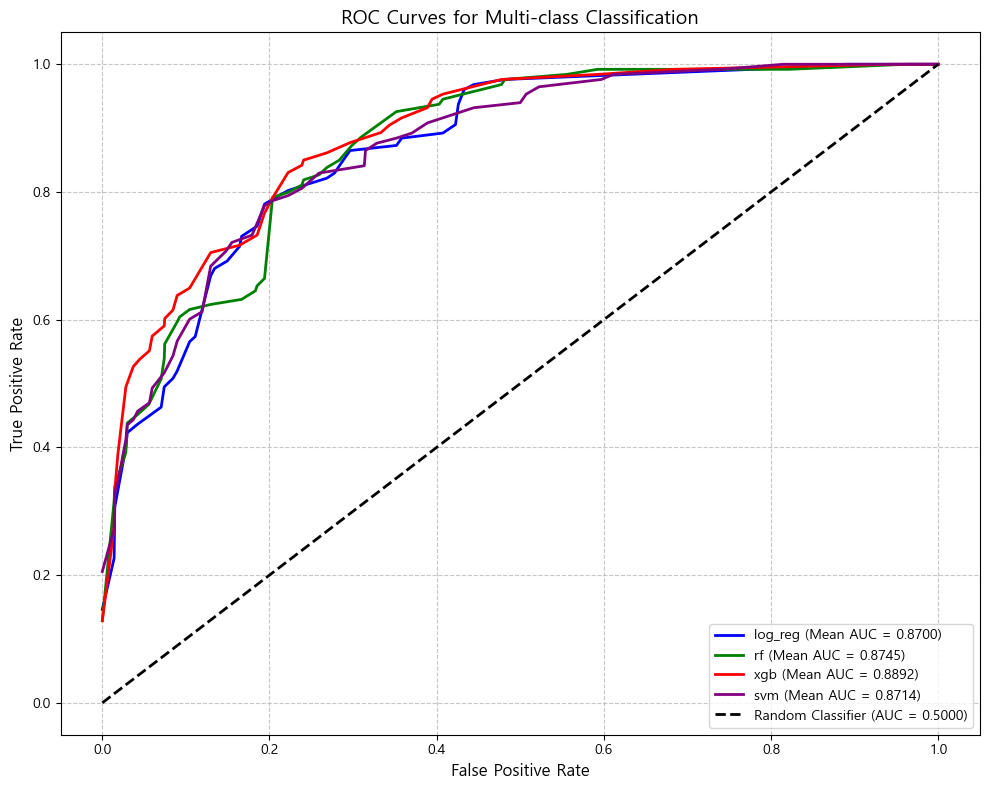

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import numpy as np

# 다중 클래스 레이블 이진화 (One-vs-Rest 방식)
n_classes = len(np.unique(y_test_encoded))
y_test_bin = label_binarize(y_test_encoded, classes=np.unique(y_test_encoded))

# 모델 이름과 색상 설정
models_ = {'log_reg': log_reg_random.best_estimator_,
            'rf': rf_random.best_estimator_,
            'xgb': xgb_random.best_estimator_,
            'svm': svm_random.best_estimator_}

colors = ['blue', 'green', 'red', 'purple']
plt.figure(figsize=(10, 8))

# 각 모델별 ROC 곡선 그리기
for i, (model_name, model) in enumerate(models_.items()):
    if hasattr(model, "predict_proba"):  # 확률값이 있는 경우
        y_proba = model.predict_proba(X_test_scaled)
    else:  # SVM 같은 경우 확률값 대신 decision_function 사용 가능
        y_proba = model.decision_function(X_test_scaled)
    
    # 각 클래스별 ROC 곡선 계산
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    
    for j in range(n_classes):
        fpr[j], tpr[j], _ = roc_curve(y_test_bin[:, j], y_proba[:, j])
        roc_auc[j] = auc(fpr[j], tpr[j])
    
    # 평균 ROC 곡선 계산 (OvR 방식)
    all_fpr = np.unique(np.concatenate([fpr[j] for j in range(n_classes)]))
    mean_tpr = np.zeros_like(all_fpr)
    
    for j in range(n_classes):
        mean_tpr += np.interp(all_fpr, fpr[j], tpr[j])
    
    mean_tpr /= n_classes
    mean_auc = auc(all_fpr, mean_tpr)
    
    # 그래프 그리기
    plt.plot(all_fpr, mean_tpr, color=colors[i], lw=2,
            label=f'{model_name} (Mean AUC = {mean_auc:.4f})')

# 무작위 분류기 기준선 추가
plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier (AUC = 0.5000)')

# 그래프 설정
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves for Multi-class Classification', fontsize=14)
plt.legend(loc="lower right", fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


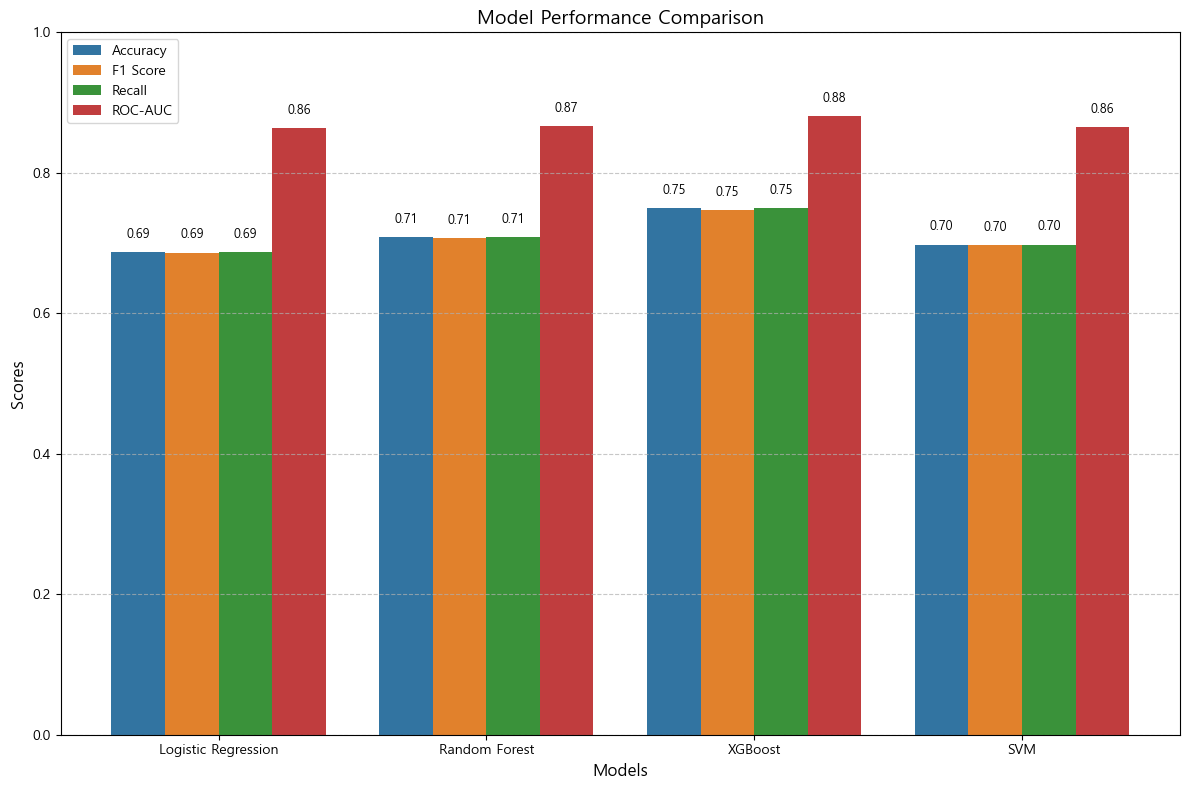

In [88]:
import matplotlib.pyplot as plt
import numpy as np

# 모델 이름
models = ['Logistic Regression', 'Random Forest', 'XGBoost', 'SVM']

# 테스트 세트 성능
accuracy = [0.6875, 0.7083, 0.7500, 0.6979]
F1_score = [0.6865, 0.7072, 0.7472, 0.6970]
recall = [0.6875, 0.7083, 0.7500, 0.6979]
roc_auc = [0.8633, 0.8672, 0.8815, 0.8650]

# 그래프 크기 설정
plt.figure(figsize=(12, 8))

# 그룹화된 바 차트 생성
x = np.arange(len(models))
width = 0.2

plt.bar(x - 1.5*width, accuracy, width, label='Accuracy', color='#3274A1')
plt.bar(x - 0.5*width, F1_score, width, label='F1 Score', color='#E1812C')
plt.bar(x + 0.5*width, recall, width, label='Recall', color='#3A923A')
plt.bar(x + 1.5*width, roc_auc, width, label='ROC-AUC', color='#C03D3E')

# 그래프 레이블 및 제목 설정
plt.xlabel('Models', fontsize=12)
plt.ylabel('Scores', fontsize=12)
plt.title('Model Performance Comparison', fontsize=14)
plt.xticks(x, models, fontsize=10)
plt.ylim(0, 1.0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(fontsize=10)

# 값 표시
for i, v in enumerate(accuracy):
    plt.text(i - 1.5*width, v + 0.02, f'{v:.2f}', ha='center', fontsize=9)
for i, v in enumerate(F1_score):
    plt.text(i - 0.5*width, v + 0.02, f'{v:.2f}', ha='center', fontsize=9)
for i, v in enumerate(recall):
    plt.text(i + 0.5*width, v + 0.02, f'{v:.2f}', ha='center', fontsize=9)
for i, v in enumerate(roc_auc):
    plt.text(i + 1.5*width, v + 0.02, f'{v:.2f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()


### 최종 선택 모델 - XGBoost
- RandomSearch CV 적용
  - 성능의 상승 폭이 크지 않았다.
- XGBoost 의 F1스코어 및 ROC-AUC가 가장 높다.

XGBoost 분류 보고서:
              precision    recall  f1-score   support

           0       0.72      0.62      0.67        29
           1       0.85      0.92      0.88        25
           2       0.70      0.74      0.72        42

    accuracy                           0.75        96
   macro avg       0.76      0.76      0.76        96
weighted avg       0.75      0.75      0.75        96



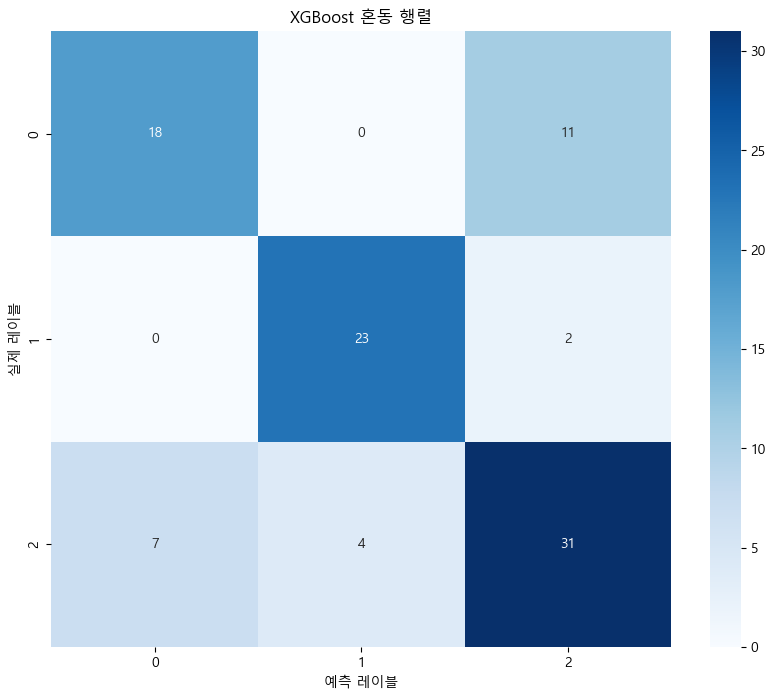

<Figure size 1200x600 with 0 Axes>

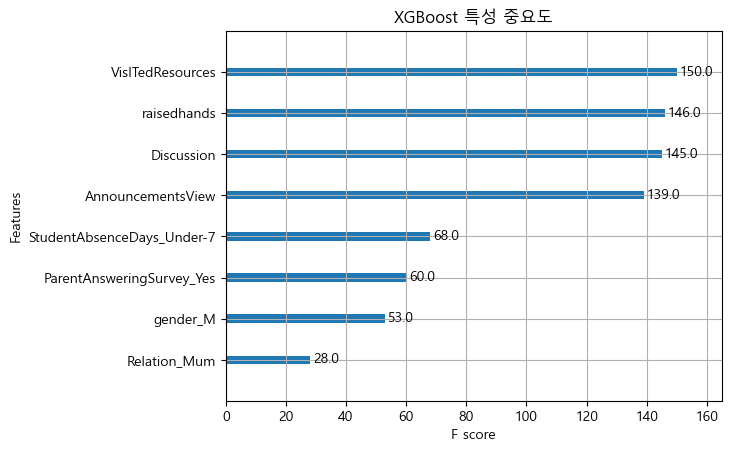

In [90]:
from xgboost import plot_importance

# 최적의 XGBoost 모델 가져오기
best_xgb_model = xgb_random.best_estimator_

# 테스트 데이터에 대한 예측 수행
y_pred = best_xgb_model.predict(X_test_scaled)

# 예측 확률값 구하기 (ROC 곡선이나 확률 분포 확인 시 필요)
y_pred_proba = best_xgb_model.predict_proba(X_test_scaled)

# 결과 평가
from sklearn.metrics import classification_report, confusion_matrix

# 분류 보고서 출력
print("XGBoost 분류 보고서:")
print(classification_report(y_test_encoded, y_pred))

# 혼동 행렬 시각화
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test_encoded, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=np.unique(y_test_encoded), 
            yticklabels=np.unique(y_test_encoded))
plt.xlabel('예측 레이블')
plt.ylabel('실제 레이블')
plt.title('XGBoost 혼동 행렬')
plt.show()

# 특성 중요도 시각화
plt.figure(figsize=(12, 6))
plot_importance(best_xgb_model, max_num_features=10)
plt.title('XGBoost 특성 중요도')
plt.show()
